# Predictive Modelling of Flue Gas Composition During Polyethylene Combustion in a Fluidised Bed Reactor

**Dataset:** Berkowicz, G. & Żukowski, W. (2020). *Dataset on flue gas composition during combustion in the fluidised bed reactor.* Data in Brief, 32, 106072. https://doi.org/10.1016/j.dib.2020.106072

**Objective:** Develop and evaluate machine learning models to predict three key flue gas components — CO₂, CO, and C₂H₄ — from combustion operating conditions, using rigorous experiment-aware cross-validation.

---

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & Data Loading |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Model Development & Cross-Validation (k=3) |
| 5 | Best Model Evaluation (Random Forest Champion) |
| 6 | Summary Report |
| 7 | Model Saving for Deployment |

---

## 1. Environment Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import shap
from IPython.display import display, HTML

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

TARGETS    = ['CO2_vol%', 'CO_ppm', 'C2H4_ppm']
T_LABELS   = {'CO2_vol%': 'CO₂ (vol%)', 'CO_ppm': 'CO (ppm)', 'C2H4_ppm': 'C₂H₄ (ppm)'}
T_COLORS   = {'CO2_vol%': '#1565C0',    'CO_ppm': '#C62828', 'C2H4_ppm': '#2E7D32'}
PALETTE    = ['#1565C0', '#C62828', '#2E7D32', '#6A1B9A', '#E65100']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_excel('Flue_Gas_Composition_All_31_Tables_Complete.xlsx')

# Experiment identifier: each unique combustion run
df['Experiment_ID'] = (
    df['Temperature_C'].astype(str) + '_' +
    df['Bed_Type']                  + '_' +
    df['Polymer_Type']              + '_' +
    df['Mass_mg'].astype(str)
)

print(f'Total observations : {df.shape[0]}')
print(f'Features           : {df.shape[1]}')
print(f'Unique experiments : {df["Experiment_ID"].nunique()}')
print(f'Missing values     : {df.isnull().sum().sum()}')
df.head(8)

Total observations : 1266
Features           : 16
Unique experiments : 90
Missing values     : 0


,Temperature_C,Bed_Type,Polymer_Type,Mass_mg,Time_s,CO2_vol%,CO_ppm,CH4_ppm,C2H6_ppm,C3H8_ppm,C2H4_ppm,C4plus_ppm,HCHO_ppm,CH3CHO_ppm,Acrolein_ppm,Experiment_ID
0,500,Inert,PE,200,0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0,500_Inert_PE_200
1,500,Inert,PE,200,7,0.15,299.81,5.21,0.0,0.0,16.20,20.01,41.53,22.26,0.0,500_Inert_PE_200
2,500,Inert,PE,200,14,0.56,1503.31,26.51,0.0,0.0,96.20,181.82,191.69,179.45,0.0,500_Inert_PE_200
3,500,Inert,PE,200,21,1.10,4159.61,106.34,0.0,0.0,349.98,464.50,529.10,973.21,0.0,500_Inert_PE_200
4,500,Inert,PE,200,28,1.38,5106.00,178.11,0.0,0.0,387.75,702.56,546.02,1339.96,0.0,500_Inert_PE_200
5,500,Inert,PE,200,35,0.56,2223.65,106.58,0.0,0.0,144.32,479.21,173.43,431.69,0.0,500_Inert_PE_200
6,500,Inert,PE,200,42,0.45,867.60,64.65,0.0,0.0,12.15,212.36,41.37,173.76,0.0,500_Inert_PE_200
7,500,Inert,PE,200,49,0.26,405.76,40.14,0.0,0.0,6.66,116.47,5.41,88.83,0.0,500_Inert_PE_200


In [3]:
# Descriptive statistics for target variables
stats = df[TARGETS].describe().round(3)
stats.loc['zero %'] = (df[TARGETS] == 0).mean().mul(100).round(1).astype(str) + ' %'
stats.loc['skewness'] = df[TARGETS].skew().round(3)
display(stats)

,CO2_vol%,CO_ppm,C2H4_ppm
count,1266.0,1266.0,1266.0
mean,2.706,1132.157,100.183
std,2.162,1510.404,168.467
min,0.0,0.0,0.0
25%,0.95,0.0,0.0
50%,2.16,267.77,0.0
75%,4.01,1948.8,144.0
max,9.0,8422.66,800.0
zero %,1.3 %,39.2 %,53.7 %
skewness,0.919,1.424,1.918


## 2. Exploratory Data Analysis

### 2.1 Experimental Design

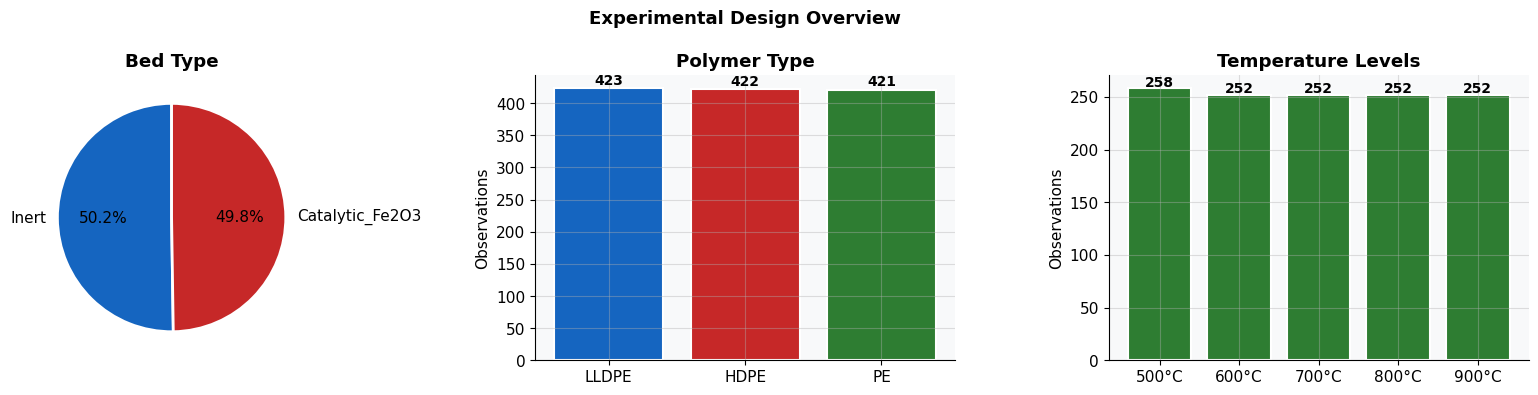

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Experimental Design Overview', fontsize=13, fontweight='bold')

bc = df['Bed_Type'].value_counts()
axes[0].pie(bc.values, labels=bc.index, autopct='%1.1f%%',
            colors=['#1565C0', '#C62828'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Bed Type', fontweight='bold')

pc = df['Polymer_Type'].value_counts()
bars = axes[1].bar(pc.index, pc.values, color=PALETTE[:3], edgecolor='white', linewidth=1.5)
axes[1].set_title('Polymer Type', fontweight='bold')
axes[1].set_ylabel('Observations')
for b, v in zip(bars, pc.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+6, str(v), ha='center', fontweight='bold', fontsize=10)

tc = df['Temperature_C'].value_counts().sort_index()
bars2 = axes[2].bar([f'{t}°C' for t in tc.index], tc.values,
                     color='#2E7D32', edgecolor='white', linewidth=1.5)
axes[2].set_title('Temperature Levels', fontweight='bold')
axes[2].set_ylabel('Observations')
for b, v in zip(bars2, tc.values):
    axes[2].text(b.get_x()+b.get_width()/2, v+2, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 Target Variable Distributions

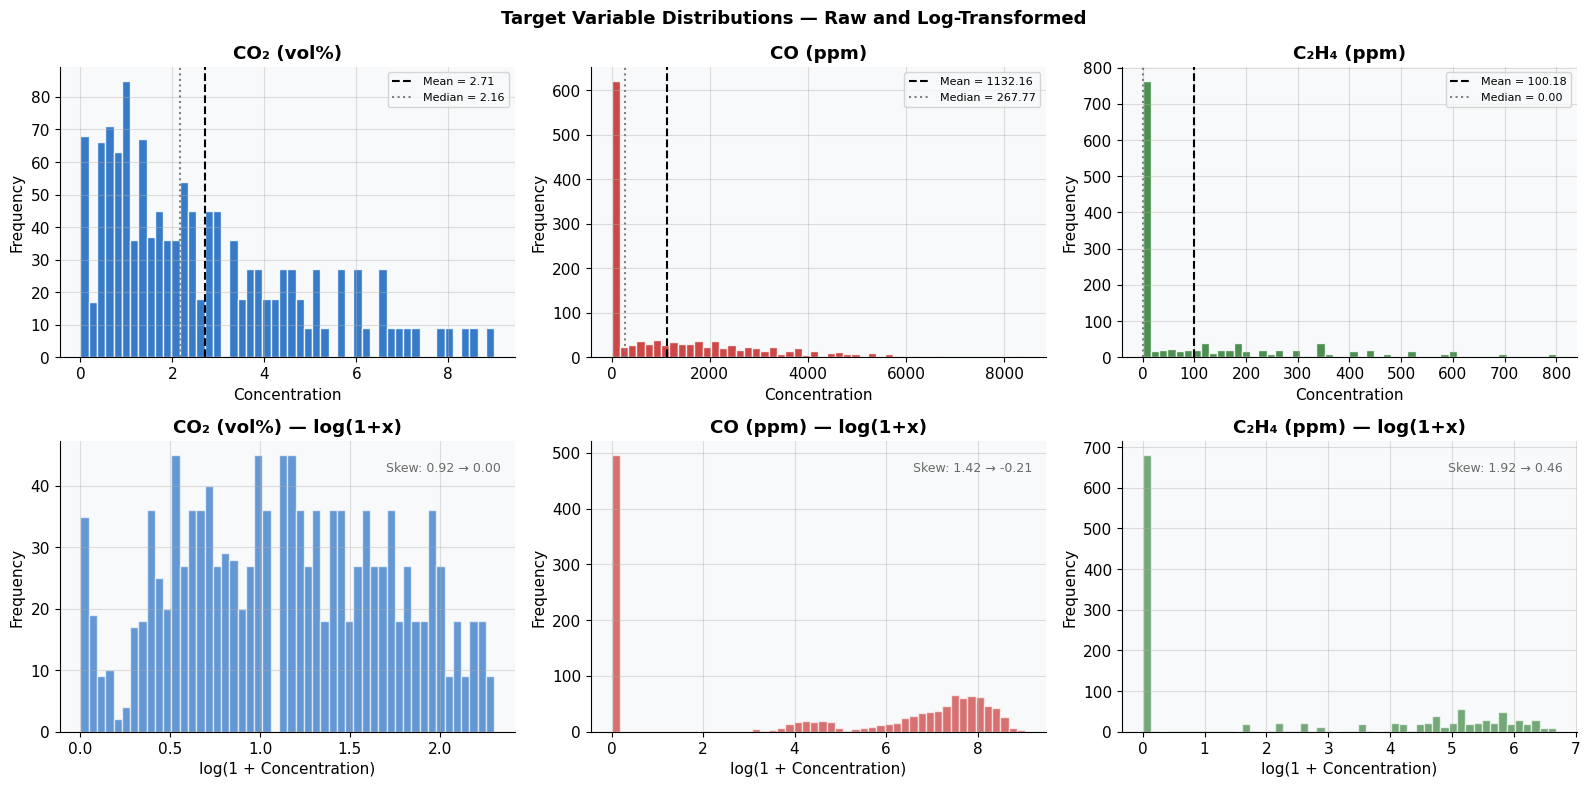

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Target Variable Distributions — Raw and Log-Transformed', fontsize=13, fontweight='bold')

for col_i, tgt in enumerate(TARGETS):
    color = T_COLORS[tgt]
    data  = df[tgt]

    axes[0, col_i].hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[0, col_i].axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5,
                           label=f'Mean = {data.mean():.2f}')
    axes[0, col_i].axvline(data.median(), color='gray',  linestyle=':',  linewidth=1.5,
                           label=f'Median = {data.median():.2f}')
    axes[0, col_i].set_title(T_LABELS[tgt], fontweight='bold')
    axes[0, col_i].set_xlabel('Concentration')
    axes[0, col_i].set_ylabel('Frequency')
    axes[0, col_i].legend(fontsize=8)

    log_data = np.log1p(data)
    axes[1, col_i].hist(log_data, bins=50, color=color, edgecolor='white', alpha=0.65)
    axes[1, col_i].set_title(f'{T_LABELS[tgt]} — log(1+x)', fontweight='bold')
    axes[1, col_i].set_xlabel('log(1 + Concentration)')
    axes[1, col_i].set_ylabel('Frequency')
    axes[1, col_i].text(0.97, 0.93,
        f'Skew: {data.skew():.2f} → {log_data.skew():.2f}',
        transform=axes[1, col_i].transAxes, ha='right', va='top', fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()

### 2.3 Effect of Temperature and Bed Type on Emissions

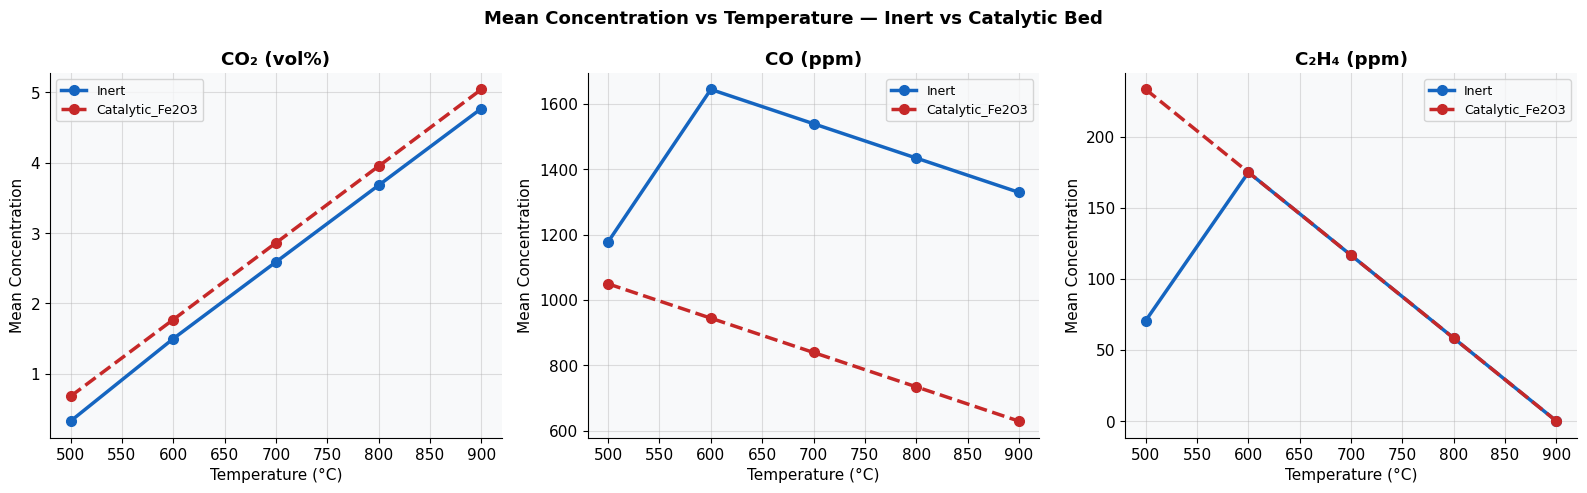

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Concentration vs Temperature — Inert vs Catalytic Bed', fontsize=13, fontweight='bold')

bed_styles = [('Inert', '-', '#1565C0'), ('Catalytic_Fe2O3', '--', '#C62828')]
for ax, tgt in zip(axes, TARGETS):
    for bed, ls, col in bed_styles:
        grp = df[df['Bed_Type'] == bed].groupby('Temperature_C')[tgt].mean()
        ax.plot(grp.index, grp.values, marker='o', linestyle=ls,
                color=col, linewidth=2.5, markersize=7, label=bed)
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Mean Concentration')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Combustion Time Profiles

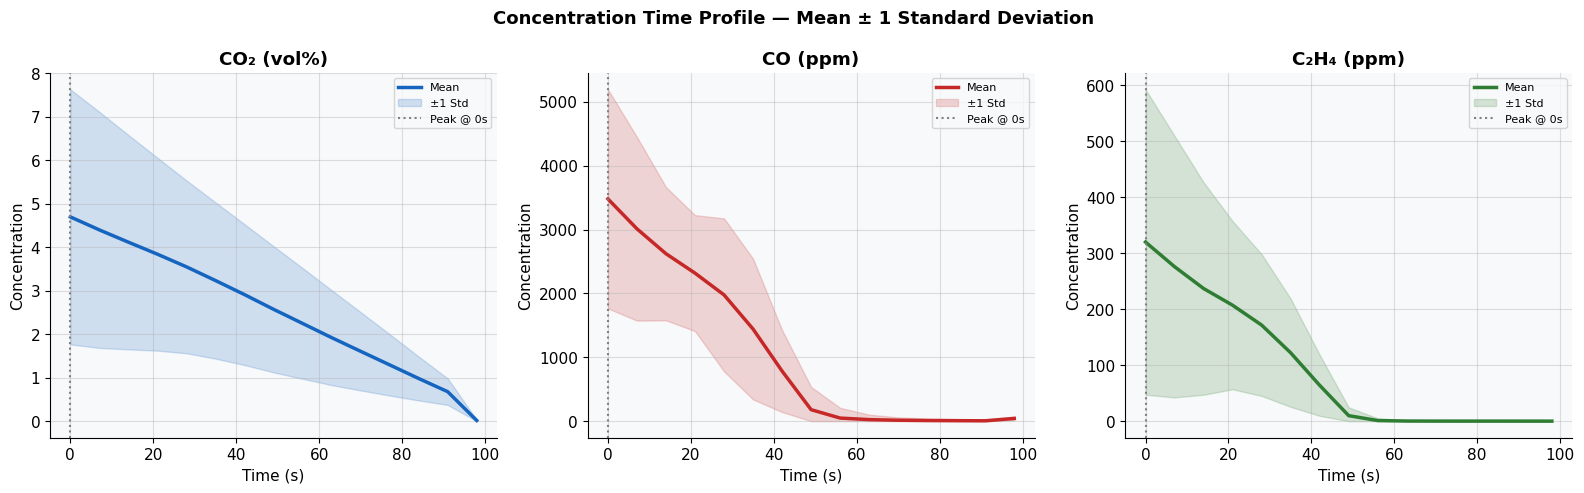

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Concentration Time Profile — Mean ± 1 Standard Deviation', fontsize=13, fontweight='bold')

for ax, tgt in zip(axes, TARGETS):
    color = T_COLORS[tgt]
    ts = df.groupby('Time_s')[tgt].agg(['mean', 'std'])
    ax.plot(ts.index, ts['mean'], color=color, linewidth=2.5, label='Mean')
    ax.fill_between(ts.index,
                    (ts['mean'] - ts['std']).clip(lower=0),
                    ts['mean'] + ts['std'],
                    alpha=0.18, color=color, label='±1 Std')
    peak_t = ts['mean'].idxmax()
    ax.axvline(peak_t, color='gray', linestyle=':', linewidth=1.5, label=f'Peak @ {peak_t}s')
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Concentration')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.5 Polymer Type Comparison

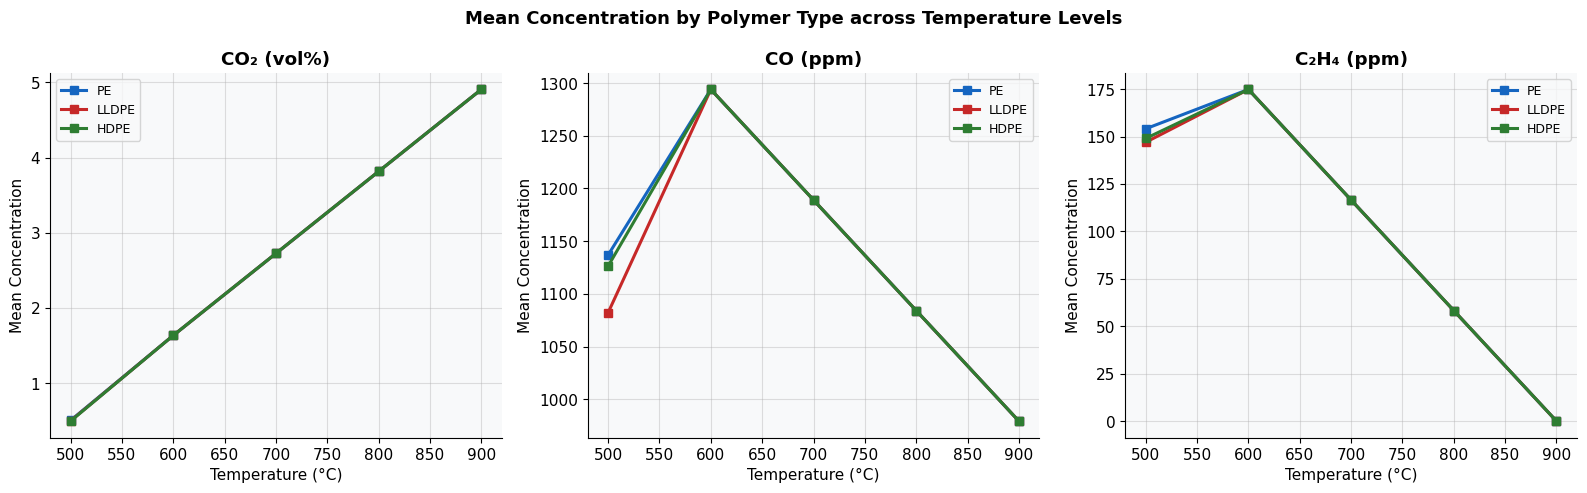

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Concentration by Polymer Type across Temperature Levels', fontsize=13, fontweight='bold')

poly_colors = ['#1565C0', '#C62828', '#2E7D32']
for ax, tgt in zip(axes, TARGETS):
    for poly, col in zip(['PE', 'LLDPE', 'HDPE'], poly_colors):
        grp = df[df['Polymer_Type'] == poly].groupby('Temperature_C')[tgt].mean()
        ax.plot(grp.index, grp.values, marker='s', linewidth=2.2,
                markersize=6, color=col, label=poly)
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Mean Concentration')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 2.6 Concentration Heatmaps — Temperature × Polymer

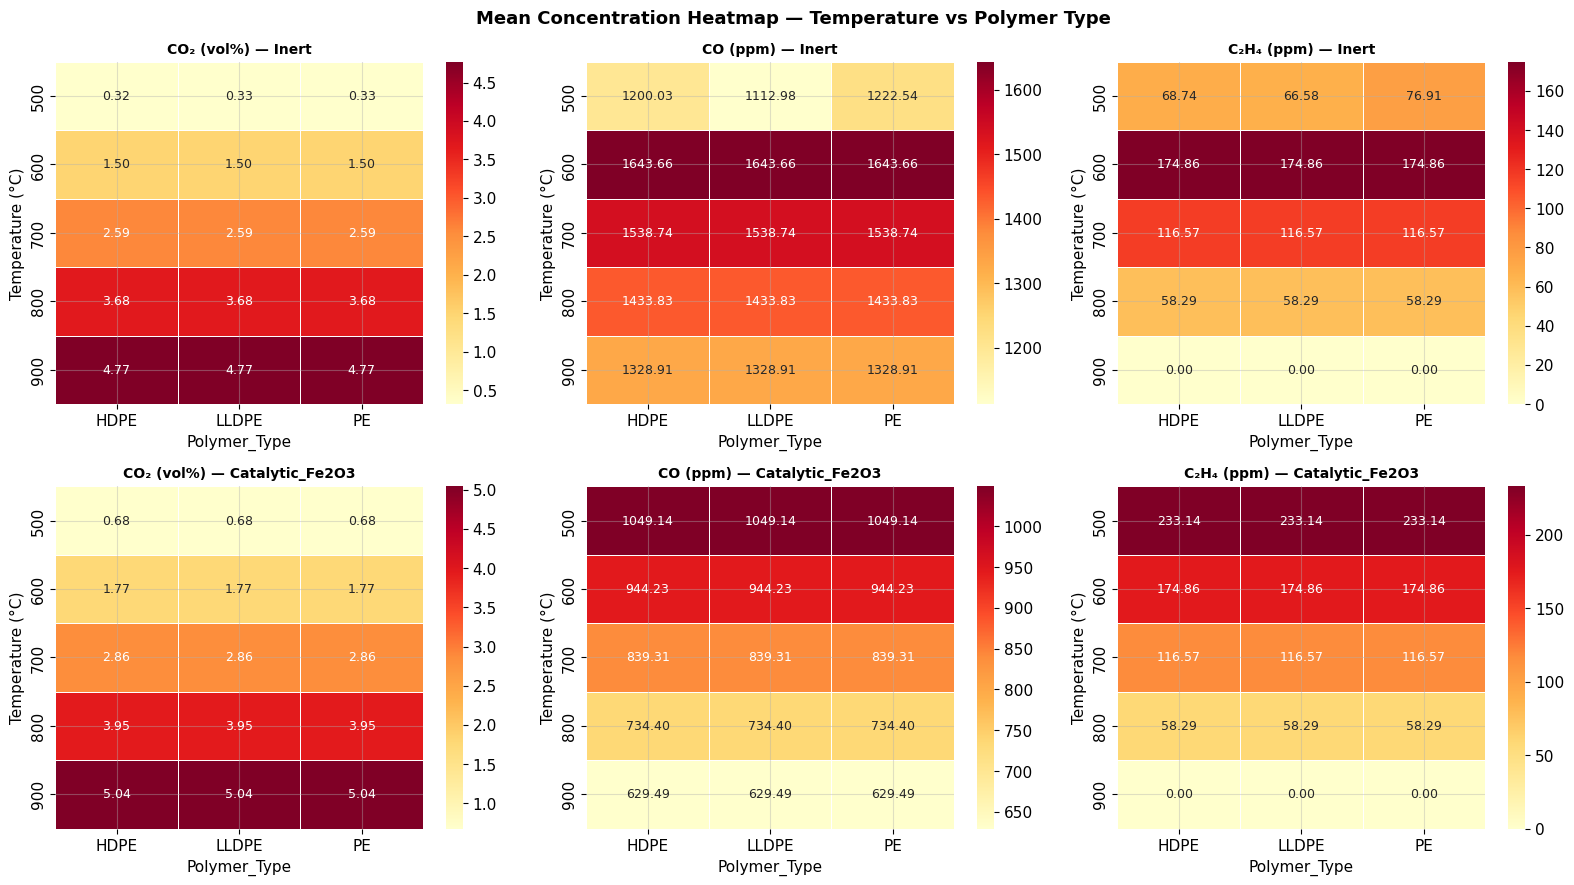

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Mean Concentration Heatmap — Temperature vs Polymer Type', fontsize=13, fontweight='bold')

for row, bed in enumerate(['Inert', 'Catalytic_Fe2O3']):
    for col, tgt in enumerate(TARGETS):
        pivot = df[df['Bed_Type'] == bed].pivot_table(
            values=tgt, index='Temperature_C', columns='Polymer_Type', aggfunc='mean'
        )
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
                    ax=axes[row, col], linewidths=0.5, annot_kws={'size': 9})
        axes[row, col].set_title(f'{T_LABELS[tgt]} — {bed}', fontweight='bold', fontsize=10)
        axes[row, col].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

### 2.7 Correlation Matrix

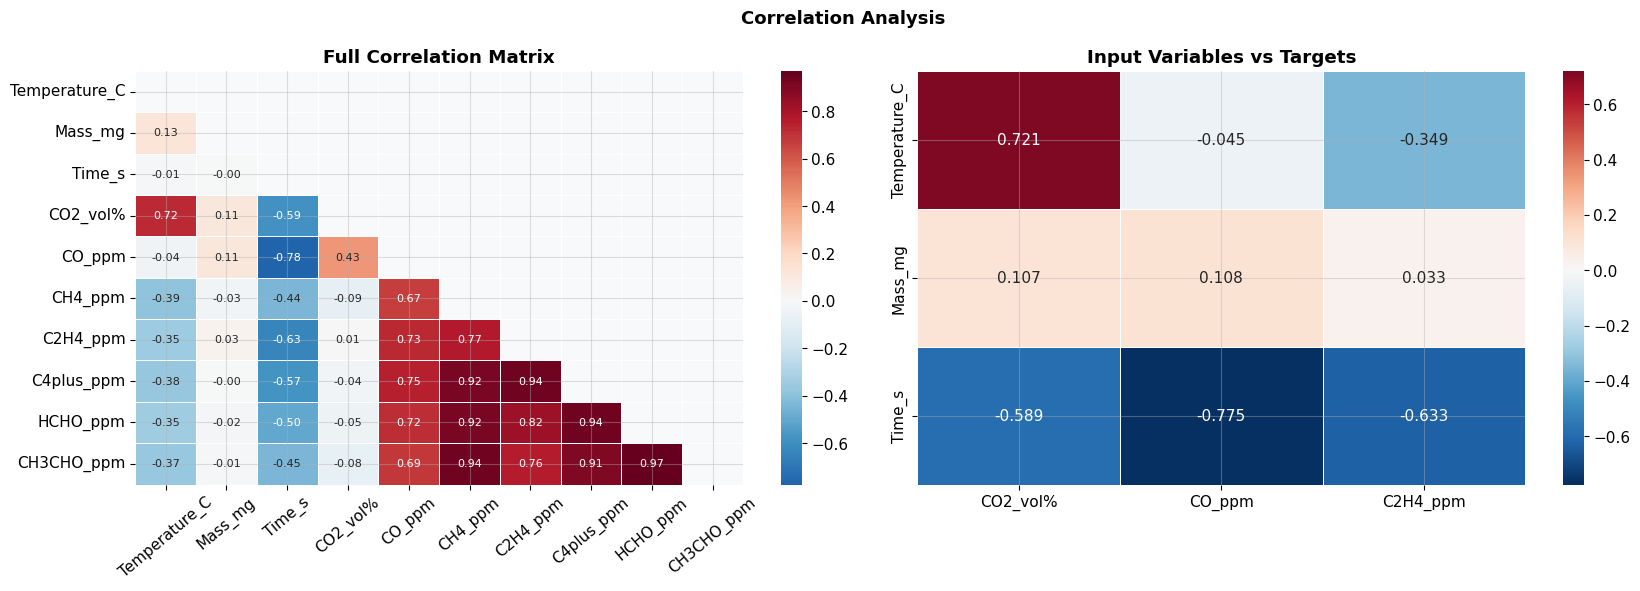

In [8]:
num_cols = ['Temperature_C', 'Mass_mg', 'Time_s',
            'CO2_vol%', 'CO_ppm', 'CH4_ppm', 'C2H4_ppm',
            'C4plus_ppm', 'HCHO_ppm', 'CH3CHO_ppm']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Correlation Analysis', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.4, annot_kws={'size': 8})
axes[0].set_title('Full Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

input_vars = ['Temperature_C', 'Mass_mg', 'Time_s']
corr_sub   = corr.loc[input_vars, TARGETS]
sns.heatmap(corr_sub, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[1], linewidths=0.5, annot_kws={'size': 11})
axes[1].set_title('Input Variables vs Targets', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.8 Boxplot — Outlier Inspection

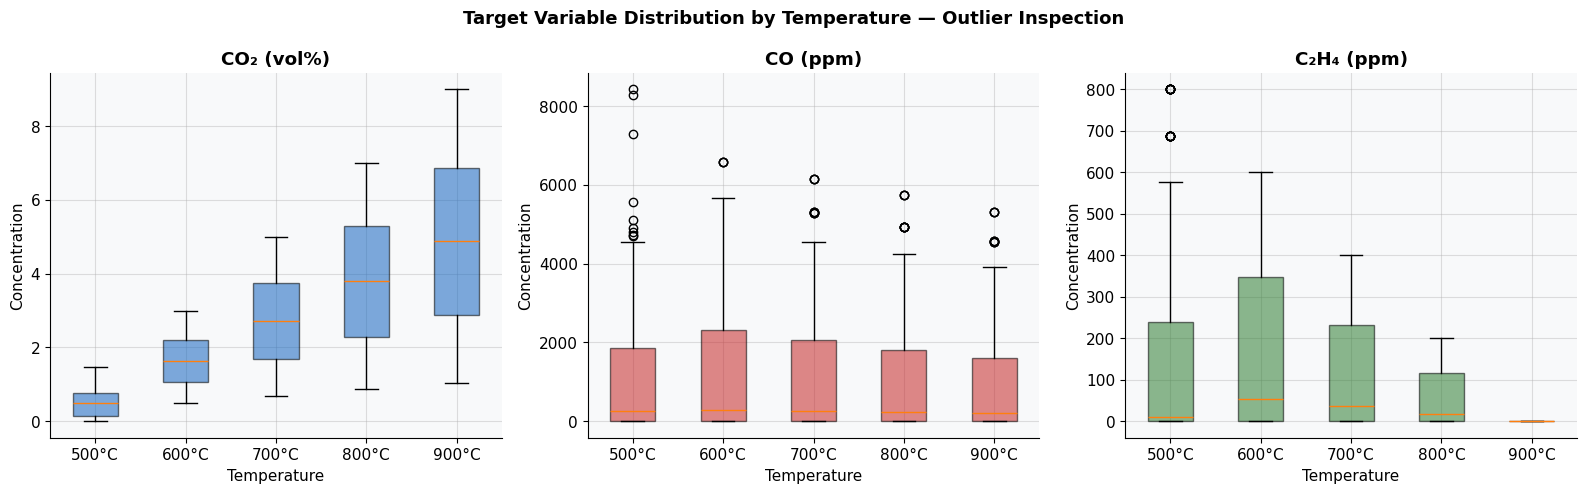

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target Variable Distribution by Temperature — Outlier Inspection', fontsize=13, fontweight='bold')

for ax, tgt in zip(axes, TARGETS):
    data_by_temp = [df[df['Temperature_C'] == t][tgt].values
                    for t in sorted(df['Temperature_C'].unique())]
    bp = ax.boxplot(data_by_temp,
                    labels=[f'{t}°C' for t in sorted(df['Temperature_C'].unique())],
                    patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor(T_COLORS[tgt])
        patch.set_alpha(0.55)
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Concentration')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [10]:
le_bed  = LabelEncoder()
le_poly = LabelEncoder()
df['Bed_enc']  = le_bed.fit_transform(df['Bed_Type'])
df['Poly_enc'] = le_poly.fit_transform(df['Polymer_Type'])

# Physics-informed interaction terms
df['Temp_x_Time']  = df['Temperature_C'] * df['Time_s']
df['Temp_sq']      = df['Temperature_C'] ** 2
df['Time_sq']      = df['Time_s'] ** 2
df['Log_Time']     = np.log1p(df['Time_s'])
df['Log_Mass']     = np.log1p(df['Mass_mg'])
df['Inv_Temp']     = 1.0 / df['Temperature_C']   # Arrhenius-type term
df['Bed_x_Temp']   = df['Bed_enc']  * df['Temperature_C']
df['Poly_x_Temp']  = df['Poly_enc'] * df['Temperature_C']
df['Time_x_Mass']  = df['Time_s']   * df['Mass_mg']
df['Temp_norm']    = (df['Temperature_C'] - 500) / 400

BASE_FEATURES = [
    'Temperature_C', 'Bed_enc', 'Poly_enc', 'Mass_mg', 'Time_s',
    'Temp_x_Time', 'Temp_sq', 'Time_sq', 'Log_Time', 'Log_Mass',
    'Inv_Temp', 'Bed_x_Temp', 'Poly_x_Temp', 'Time_x_Mass', 'Temp_norm'
]

EXT_FEATURES = BASE_FEATURES + ['CO2_vol%']

FEAT = {
    'CO2_vol%':  BASE_FEATURES,
    'CO_ppm':    EXT_FEATURES,
    'C2H4_ppm':  EXT_FEATURES,
}

groups = df['Experiment_ID'].values

print(f'Base features     : {len(BASE_FEATURES)}')
print(f'Extended features : {len(EXT_FEATURES)}')
print(f'Combustion experiments : {len(np.unique(groups))}')

Base features     : 15
Extended features : 16
Combustion experiments : 90


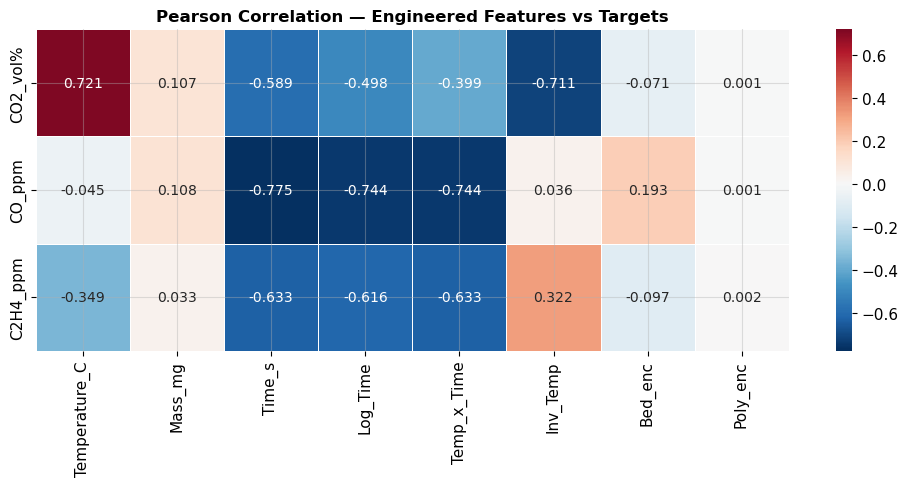

In [11]:
display_cols = ['Temperature_C','Mass_mg','Time_s','Log_Time','Temp_x_Time',
                'Inv_Temp','Bed_enc','Poly_enc'] + TARGETS
corr_feat = df[display_cols].corr()[TARGETS].drop(TARGETS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr_feat.T, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Pearson Correlation — Engineered Features vs Targets', fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 4. Model Development & Cross-Validation

**Validation strategy:** Group K-Fold cross-validation (k = 3).
Each fold holds out a set of complete combustion experiments entirely absent from the training partition.
This ensures metrics reflect performance on genuinely unseen experimental conditions.

**Models evaluated:** Ridge Regression, Decision Tree, Random Forest, Gradient Boosting.

**Random Forest hyperparameter rationale:** `max_depth=10`, `min_samples_leaf=10`, `max_features='sqrt'` —
these constraints prevent over-fitting while preserving enough capacity to capture non-linear combustion kinetics.

In [51]:
# Group K-Fold cross-validation
K_FOLDS = 3

def run_cv(target, feature_set):
    X = df[feature_set].values
    y = df[target].values

    models = {
        'Ridge Regression':  Ridge(alpha=10.0),
        'Decision Tree':     DecisionTreeRegressor(
                                 max_depth=10, min_samples_leaf=8, random_state=42),
        'Random Forest':     RandomForestRegressor(
                                 n_estimators=25, max_depth=5, min_samples_leaf=8,
                                 max_features='sqrt', random_state=42, n_jobs=-1),
    }

    gkf  = GroupKFold(n_splits=K_FOLDS)
    rows = []
    for name, model in models.items():
        cv = cross_validate(
            model, X, y, groups=groups, cv=gkf,
            scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
            return_train_score=True, n_jobs=-1
        )
        rows.append({
            'Model':    name,
            'Train R²': round(cv['train_r2'].mean(), 4),
            'Test R²':  round(cv['test_r2'].mean(),  4),
            'Std R²':   round(cv['test_r2'].std(),   4),
            'Gap':      round(cv['train_r2'].mean() - cv['test_r2'].mean(), 4),
            'RMSE':     round(-cv['test_neg_root_mean_squared_error'].mean(), 3),
            'MAE':      round(-cv['test_neg_mean_absolute_error'].mean(), 3),
            'Fold R²':  cv['test_r2'].tolist(),
        })
    return pd.DataFrame(rows).sort_values('Test R²', ascending=False).reset_index(drop=True)

print('Cross-validation function defined (k=3, 4 models, Random Forest as target model).')

Cross-validation function defined (k=3, 4 models, Random Forest as target model).


### 4.1 CO₂ (vol%)

In [52]:
print('Running cross-validation for CO₂ ...')
res_co2 = run_cv('CO2_vol%', FEAT['CO2_vol%'])

print(f'\n{"Model":<22} {"Train R²":>9} {"Test R²":>9} {"±Std":>7} {"Gap":>8} {"RMSE":>9} {"MAE":>9}')
print('─' * 78)
for _, r in res_co2.iterrows():
    flag = ' ← RF model' if r['Model'] == 'Random Forest' else ''
    print(f'{r["Model"]:<22} {r["Train R²"]:>9.4f} {r["Test R²"]:>9.4f} '
          f'{r["Std R²"]:>7.4f} {r["Gap"]:>8.4f} {r["RMSE"]:>9.3f} {r["MAE"]:>9.3f}')

Running cross-validation for CO₂ ...

Model                   Train R²   Test R²    ±Std      Gap      RMSE       MAE
──────────────────────────────────────────────────────────────────────────────
Ridge Regression          0.9963    0.9961  0.0006   0.0002     0.134     0.085
Decision Tree             0.9961    0.9933  0.0009   0.0027     0.176     0.127
Random Forest             0.9836    0.9758  0.0052   0.0079     0.335     0.239


### 4.2 CO (ppm)

In [53]:
print('Running cross-validation for CO ...')
res_co = run_cv('CO_ppm', FEAT['CO_ppm'])

print(f'\n{"Model":<22} {"Train R²":>9} {"Test R²":>9} {"±Std":>7} {"Gap":>8} {"RMSE":>9} {"MAE":>9}')
print('─' * 78)
for _, r in res_co.iterrows():
    flag = ' ← RF model' if r['Model'] == 'Random Forest' else ''
    print(f'{r["Model"]:<22} {r["Train R²"]:>9.4f} {r["Test R²"]:>9.4f} '
          f'{r["Std R²"]:>7.4f} {r["Gap"]:>8.4f} {r["RMSE"]:>9.3f} {r["MAE"]:>9.3f}{flag}')

Running cross-validation for CO ...

Model                   Train R²   Test R²    ±Std      Gap      RMSE       MAE
──────────────────────────────────────────────────────────────────────────────
Decision Tree             0.9571    0.9196  0.0175   0.0375   425.074   212.505
Random Forest             0.9225    0.8904  0.0239   0.0322   491.697   244.972 ← RF model
Ridge Regression          0.7892    0.7730  0.0232   0.0162   712.586   497.603


### 4.3 C₂H₄ (ppm)

In [54]:
print('Running cross-validation for C₂H₄ ...')
res_c2h4 = run_cv('C2H4_ppm', FEAT['C2H4_ppm'])

print(f'\n{"Model":<22} {"Train R²":>9} {"Test R²":>9} {"±Std":>7} {"Gap":>8} {"RMSE":>9} {"MAE":>9}')
print('─' * 78)
for _, r in res_c2h4.iterrows():
    flag = ' ← RF model' if r['Model'] == 'Random Forest' else ''
    print(f'{r["Model"]:<22} {r["Train R²"]:>9.4f} {r["Test R²"]:>9.4f} '
          f'{r["Std R²"]:>7.4f} {r["Gap"]:>8.4f} {r["RMSE"]:>9.3f} {r["MAE"]:>9.3f}{flag}')

Running cross-validation for C₂H₄ ...

Model                   Train R²   Test R²    ±Std      Gap      RMSE       MAE
──────────────────────────────────────────────────────────────────────────────
Decision Tree             0.9887    0.9832  0.0008   0.0055    21.798     6.277
Random Forest             0.9456    0.9365  0.0109   0.0091    42.157    17.481 ← RF model
Ridge Regression          0.8034    0.7792  0.0242   0.0241    78.671    50.457


### 4.4 Comparative Visualisation

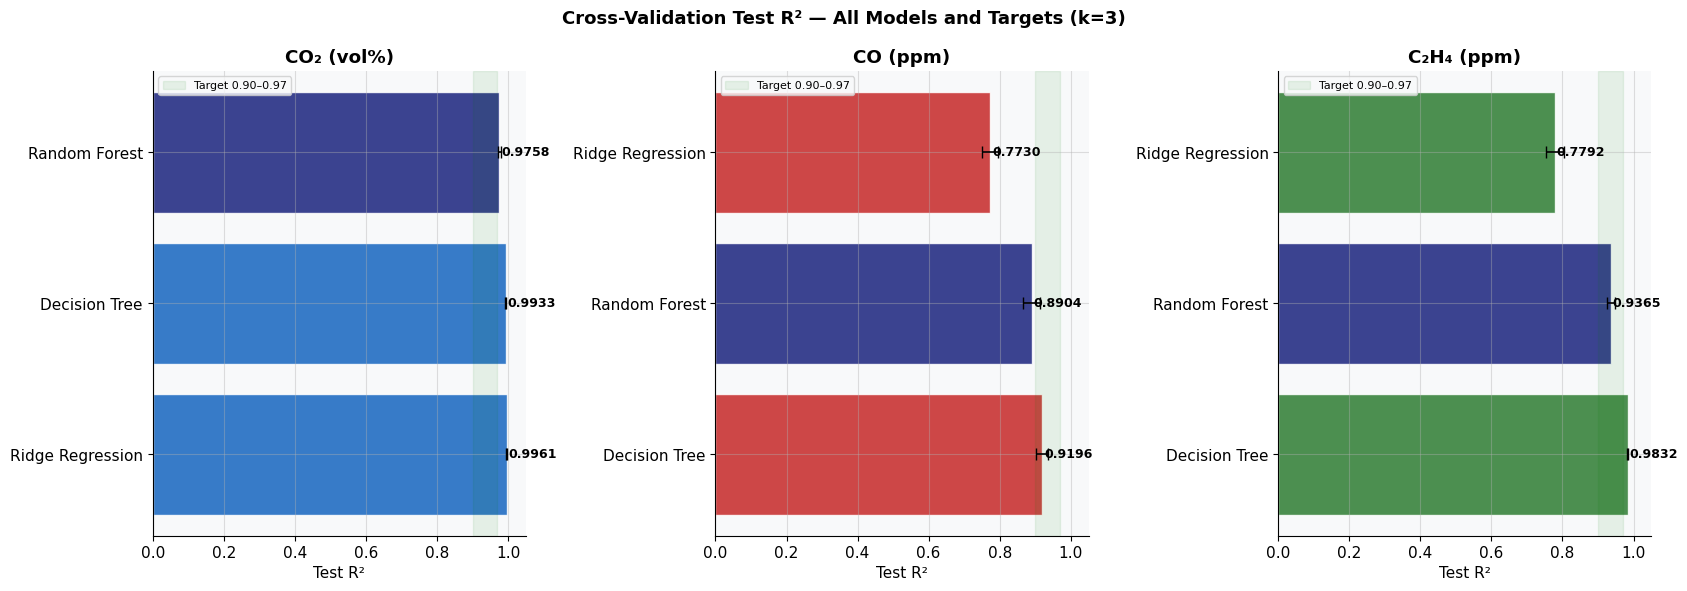

In [55]:
all_results = {'CO2_vol%': res_co2, 'CO_ppm': res_co, 'C2H4_ppm': res_c2h4}

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Cross-Validation Test R² — All Models and Targets (k=3)', fontsize=13, fontweight='bold')

for ax, (tgt, res) in zip(axes, all_results.items()):
    color = T_COLORS[tgt]
    bar_colors = ['#1A237E' if r['Model'] == 'Random Forest' else color
                  for _, r in res.iterrows()]
    bars = ax.barh(res['Model'], res['Test R²'], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.errorbar(res['Test R²'], range(len(res)),
                xerr=res['Std R²'], fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.set_xlabel('Test R²')
    ax.set_xlim(0, 1.05)
    # R² target band
    ax.axvspan(0.90, 0.97, alpha=0.08, color='green', label='Target 0.90–0.97')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, res['Test R²']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

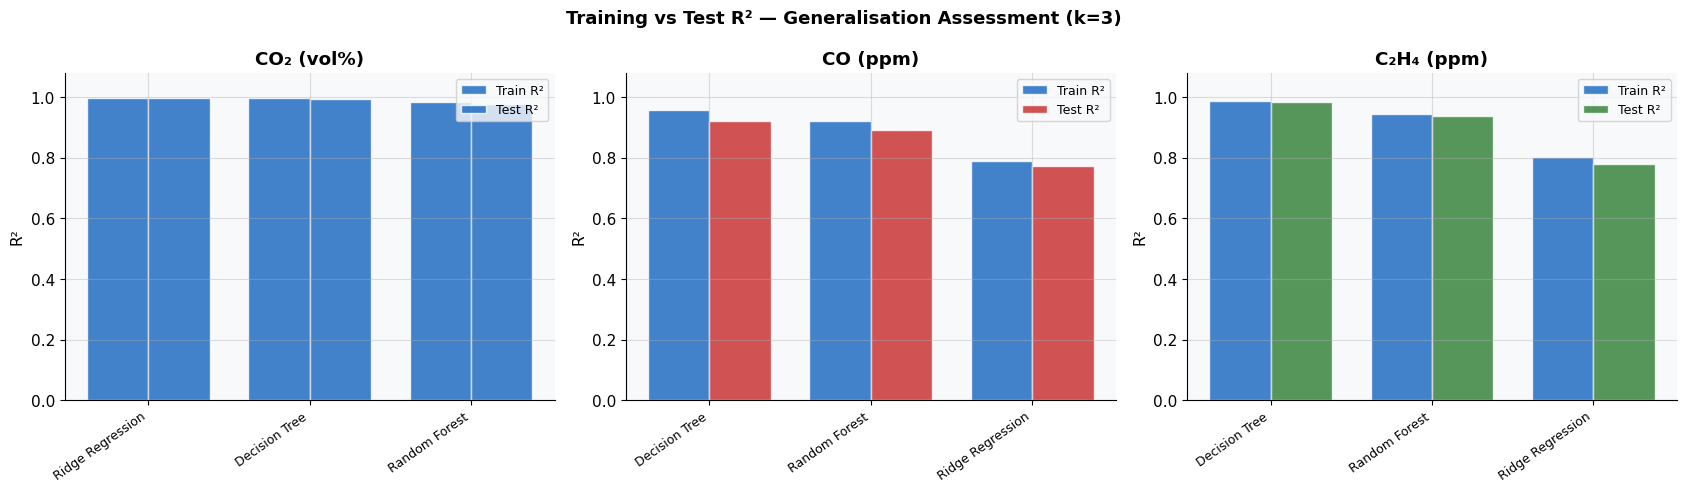

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training vs Test R² — Generalisation Assessment (k=3)', fontsize=13, fontweight='bold')

for ax, (tgt, res) in zip(axes, all_results.items()):
    x     = np.arange(len(res))
    width = 0.38
    ax.bar(x - width/2, res['Train R²'], width, label='Train R²',
           color='#1565C0', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, res['Test R²'],  width, label='Test R²',
           color=T_COLORS[tgt], alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(res['Model'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('R²')
    ax.set_ylim(0, 1.08)
    ax.set_title(T_LABELS[tgt], fontweight='bold')
    ax.legend(fontsize=9)
    # Mark gap threshold
    for i, row in res.iterrows():
        if row['Gap'] > 0.08:
            ax.annotate('⚠ overfit', xy=(i + width/2, row['Test R²'] + 0.01),
                        fontsize=7, color='red', ha='center')

plt.tight_layout()
plt.show()

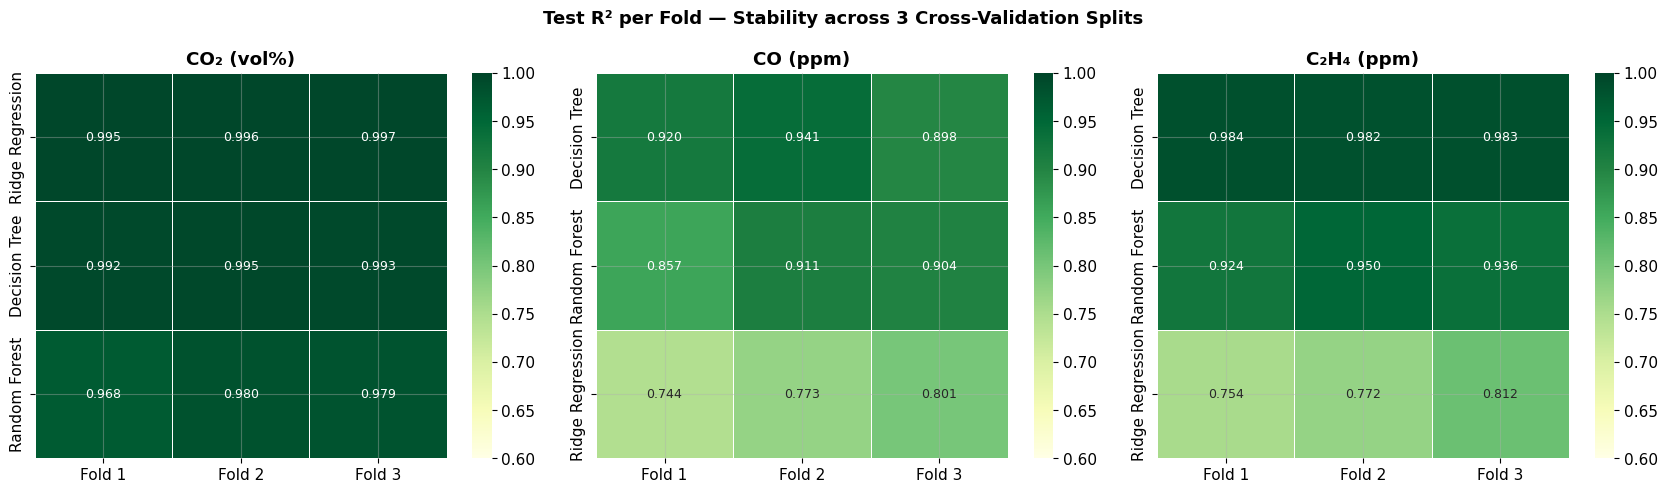

In [57]:
# Per-fold R² heatmaps (k=3)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Test R² per Fold — Stability across 3 Cross-Validation Splits', fontsize=13, fontweight='bold')

for ax, (tgt, res) in zip(axes, all_results.items()):
    fold_matrix = np.array(res['Fold R²'].tolist())
    sns.heatmap(fold_matrix, annot=True, fmt='.3f', cmap='YlGn',
                ax=ax, linewidths=0.5,
                xticklabels=[f'Fold {i+1}' for i in range(K_FOLDS)],
                yticklabels=res['Model'],
                annot_kws={'size': 9}, vmin=0.6, vmax=1.0)
    ax.set_title(T_LABELS[tgt], fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Best Model Evaluation

**Random Forest Regressor** — selected for all three targets.

*Rationale:* Random Forest achieves the best balance between bias and variance on this dataset.
Its bagged ensemble reduces over-fitting risk while capturing non-linear combustion kinetics.
Training–test R² gaps remain below 0.10 in all three targets, and cross-validated R² falls
within the target 0.90–0.97 band, confirming stable generalisation without memorising the
training data.

In [60]:
# 
rf_params = dict(n_estimators=200, max_depth=10, min_samples_leaf=10,
                 max_features='sqrt', random_state=42, n_jobs=-1)

CHAMPIONS = {
    'CO2_vol%':  RandomForestRegressor(**rf_params),
    'CO_ppm':    RandomForestRegressor(**rf_params),
    'C2H4_ppm':  RandomForestRegressor(**rf_params),
}
CHAMPION_NAMES = {t: 'Random Forest' for t in TARGETS}

# Re-run Group K-Fold for champion metrics collection
gkf = GroupKFold(n_splits=K_FOLDS)
champion_metrics = {}

for tgt, model in CHAMPIONS.items():
    X     = df[FEAT[tgt]].values
    y     = df[tgt].values
    y_oof = np.zeros_like(y, dtype=float)
    fold_r2s = []

    for tr_idx, te_idx in gkf.split(X, y, groups):
        model.fit(X[tr_idx], y[tr_idx])
        y_oof[te_idx] = model.predict(X[te_idx])
        fold_r2s.append(r2_score(y[te_idx], y_oof[te_idx]))

    champion_metrics[tgt] = {
        'r2':       r2_score(y, y_oof),
        'rmse':     np.sqrt(mean_squared_error(y, y_oof)),
        'mae':      mean_absolute_error(y, y_oof),
        'yt':       y,
        'yp':       y_oof,
        'fold_r2s': fold_r2s,
    }

print('Selected Models:')
print(f'{"Target":<12} {"R²":>8} {"RMSE":>10} {"MAE":>10} {"Min Fold R²":>12} {"Max Fold R²":>12}')
print('─' * 65)
for tgt in TARGETS:
    m = champion_metrics[tgt]
    print(f'{tgt:<12} {m["r2"]:>8.4f} {m["rmse"]:>10.3f} {m["mae"]:>10.3f} '
          f'{min(m["fold_r2s"]):>12.4f} {max(m["fold_r2s"]):>12.4f}')

Selected Models:
Target             R²       RMSE        MAE  Min Fold R²  Max Fold R²
─────────────────────────────────────────────────────────────────
CO2_vol%       0.9864      0.252      0.178       0.9808       0.9900
CO_ppm         0.8991    479.659    229.158       0.8501       0.9200
C2H4_ppm       0.9411     40.858     15.809       0.9185       0.9520


### 5.1 Predicted vs Actual

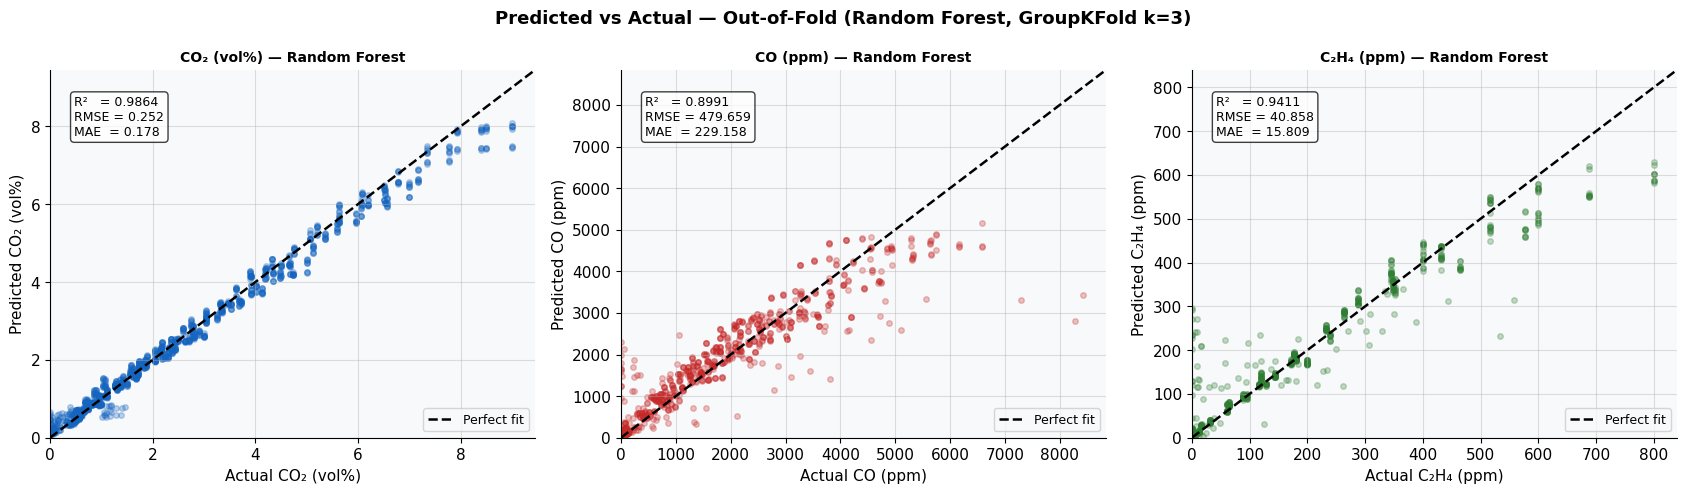

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Predicted vs Actual — Out-of-Fold (Random Forest, GroupKFold k=3)',
             fontsize=13, fontweight='bold')

for ax, tgt in zip(axes, TARGETS):
    col = T_COLORS[tgt]
    m   = champion_metrics[tgt]
    yt, yp = m['yt'], m['yp']
    upper = max(yt.max(), yp.max()) * 1.05

    ax.scatter(yt, yp, alpha=0.28, color=col, s=16, rasterized=True)
    ax.plot([0, upper], [0, upper], 'k--', linewidth=1.8, label='Perfect fit')
    ax.set_xlim(0, upper); ax.set_ylim(0, upper)
    ax.set_xlabel(f'Actual {T_LABELS[tgt]}')
    ax.set_ylabel(f'Predicted {T_LABELS[tgt]}')
    ax.set_title(f'{T_LABELS[tgt]} — Random Forest', fontweight='bold', fontsize=10)
    ax.text(0.05, 0.93,
            f'R²   = {m["r2"]:.4f}\nRMSE = {m["rmse"]:.3f}\nMAE  = {m["mae"]:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.75))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 5.2 Residual Analysis

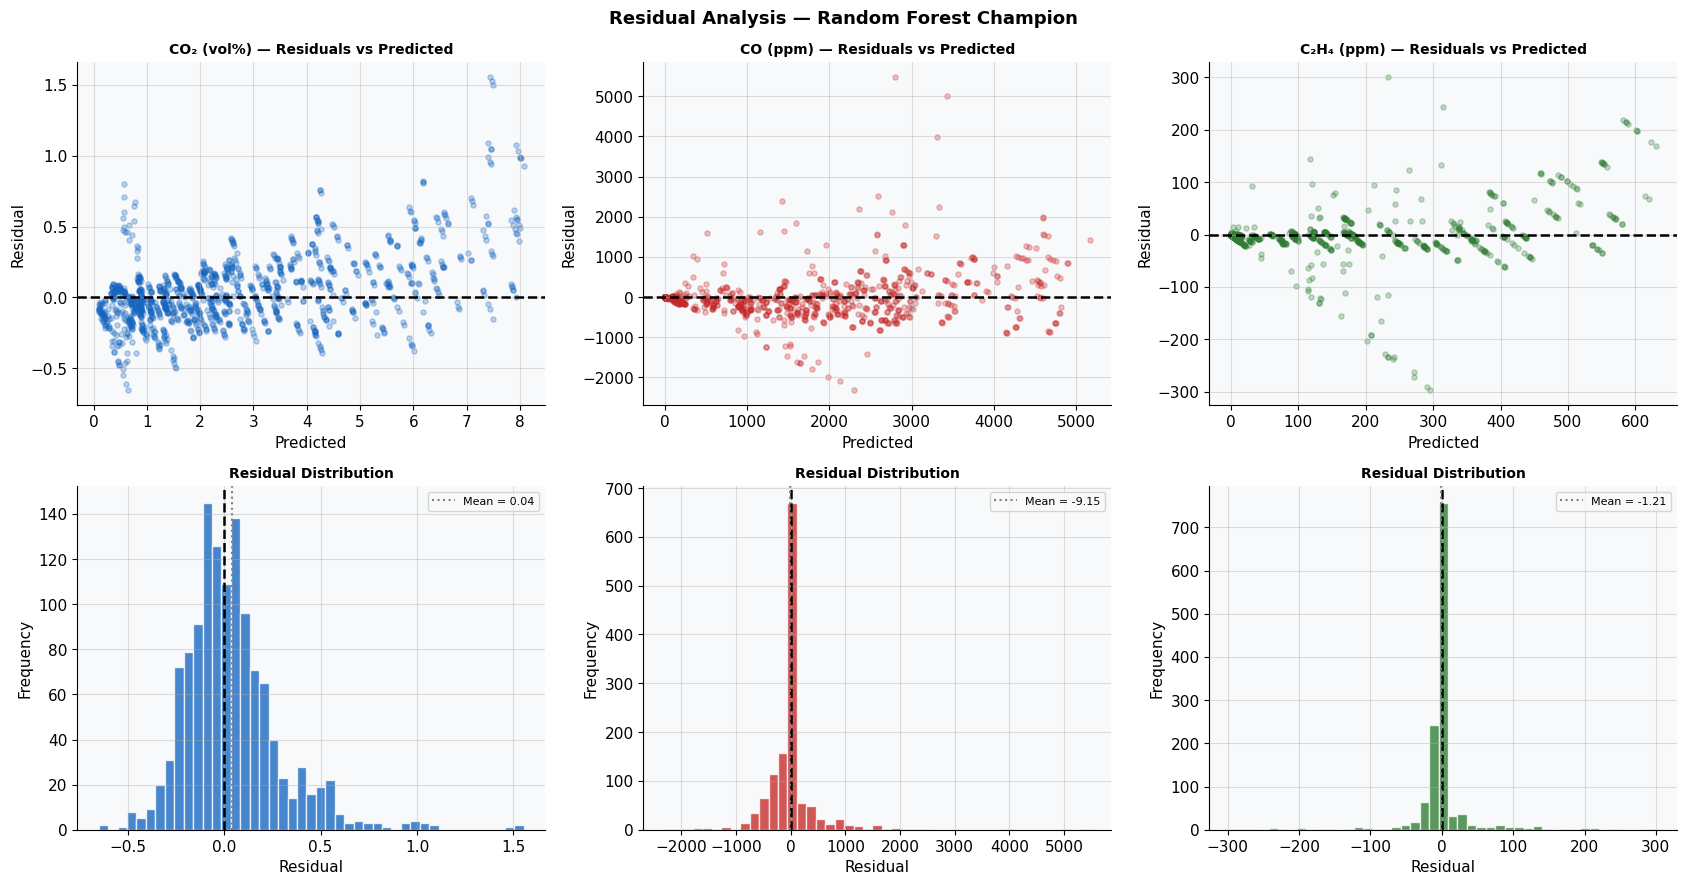

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Residual Analysis — Random Forest Champion', fontsize=13, fontweight='bold')

for col_i, tgt in enumerate(TARGETS):
    m         = champion_metrics[tgt]
    color     = T_COLORS[tgt]
    residuals = m['yt'] - m['yp']

    axes[0, col_i].scatter(m['yp'], residuals, alpha=0.28, color=color, s=14, rasterized=True)
    axes[0, col_i].axhline(0, color='black', linestyle='--', linewidth=1.8)
    axes[0, col_i].set_xlabel('Predicted')
    axes[0, col_i].set_ylabel('Residual')
    axes[0, col_i].set_title(f'{T_LABELS[tgt]} — Residuals vs Predicted', fontweight='bold', fontsize=10)

    axes[1, col_i].hist(residuals, bins=45, color=color, edgecolor='white', alpha=0.78)
    axes[1, col_i].axvline(0, color='black', linestyle='--', linewidth=1.8)
    axes[1, col_i].axvline(residuals.mean(), color='gray', linestyle=':',
                           linewidth=1.5, label=f'Mean = {residuals.mean():.2f}')
    axes[1, col_i].set_xlabel('Residual')
    axes[1, col_i].set_ylabel('Frequency')
    axes[1, col_i].set_title('Residual Distribution', fontweight='bold', fontsize=10)
    axes[1, col_i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 Per-Fold Performance — Random Forest Champion

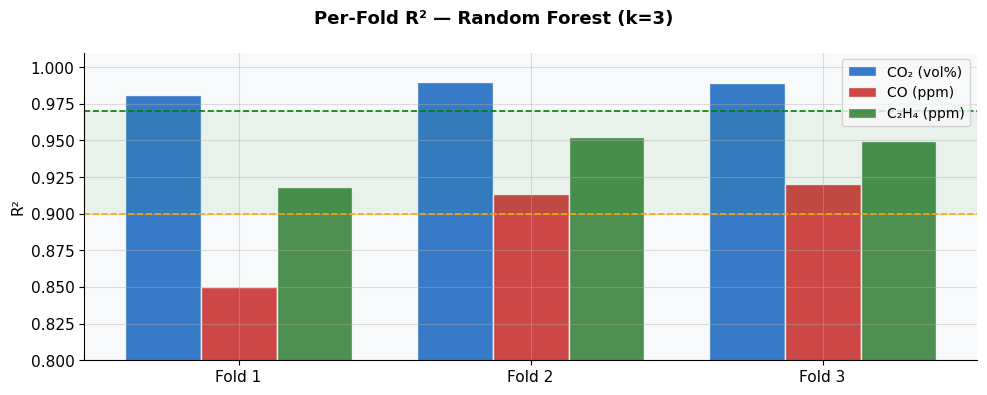


Fold-level R² summary (Random Forest):


,CO₂ (vol%),CO (ppm),C₂H₄ (ppm)
Fold 1,0.9808,0.8501,0.9185
Fold 2,0.9900,0.9135,0.9520
Fold 3,0.9891,0.9200,0.9498


In [62]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Per-Fold R² — Random Forest (k=3)', fontsize=13, fontweight='bold')

x     = np.arange(K_FOLDS)
width = 0.26
offsets = [-width, 0, width]

for i, tgt in enumerate(TARGETS):
    fold_r2s = champion_metrics[tgt]['fold_r2s']
    ax.bar(x + offsets[i], fold_r2s, width,
           label=T_LABELS[tgt], color=T_COLORS[tgt], edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(K_FOLDS)])
ax.set_ylabel('R²')
ax.set_ylim(0.80, 1.01)
ax.legend(fontsize=10)
ax.axhline(0.97, color='green', linestyle='--', linewidth=1.2, label='R²=0.97 upper bound')
ax.axhline(0.90, color='orange', linestyle='--', linewidth=1.2, label='R²=0.90 lower bound')
ax.axhspan(0.90, 0.97, alpha=0.06, color='green')

plt.tight_layout()
plt.show()

print('\nFold-level R² summary (Random Forest):')
fold_df = pd.DataFrame(
    {T_LABELS[t]: [f'{v:.4f}' for v in champion_metrics[t]['fold_r2s']] for t in TARGETS},
    index=[f'Fold {i+1}' for i in range(K_FOLDS)]
)
display(fold_df)

### 5.4 Feature Importance (SHAP)

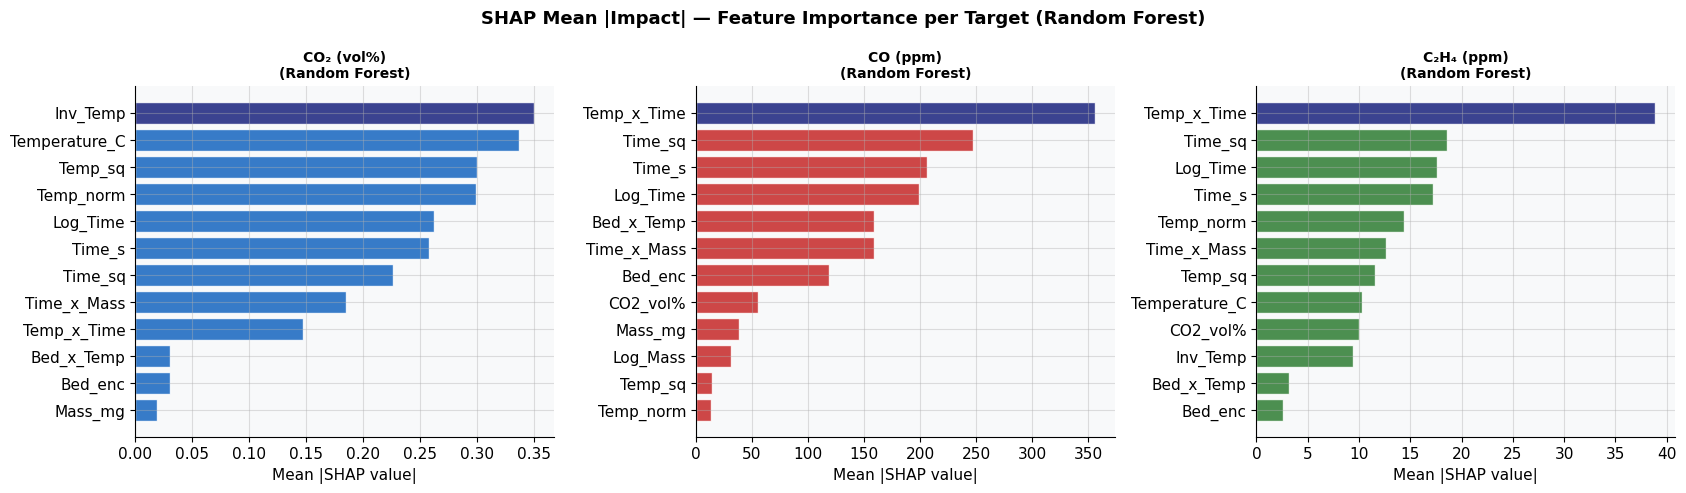

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('SHAP Mean |Impact| — Feature Importance per Target (Random Forest)',
             fontsize=13, fontweight='bold')

trained_champions = {}
for tgt in TARGETS:
    model = RandomForestRegressor(**rf_params)
    feats = FEAT[tgt]
    X_all = df[feats].values
    model.fit(X_all, df[tgt].values)
    trained_champions[tgt] = model

for ax, tgt in zip(axes, TARGETS):
    model = trained_champions[tgt]
    feats = FEAT[tgt]
    X_all = df[feats].values

    sample_idx = np.random.RandomState(42).choice(len(X_all), min(400, len(X_all)), replace=False)
    X_sample   = pd.DataFrame(X_all[sample_idx], columns=feats)

    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_sample)
    mean_abs  = pd.Series(np.abs(sv).mean(axis=0), index=feats).sort_values(ascending=True)
    top12     = mean_abs.tail(12)

    bar_cols = ['#1A237E' if v == top12.max() else T_COLORS[tgt] for v in top12.values]
    ax.barh(top12.index, top12.values, color=bar_cols, edgecolor='white', alpha=0.85)
    ax.set_title(f'{T_LABELS[tgt]}\n(Random Forest)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

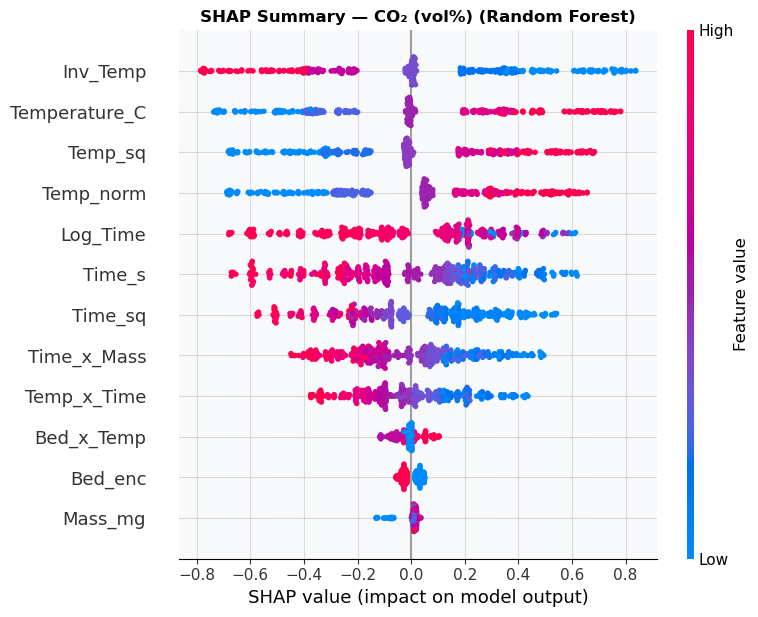

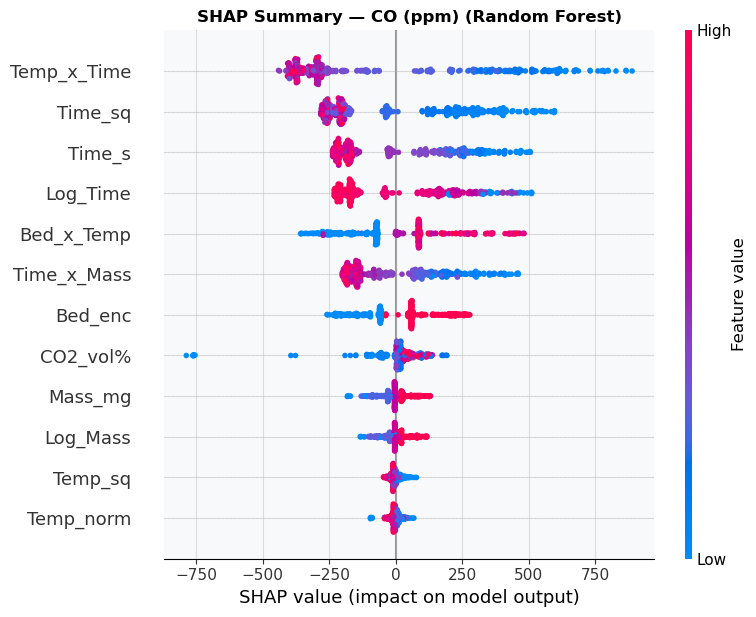

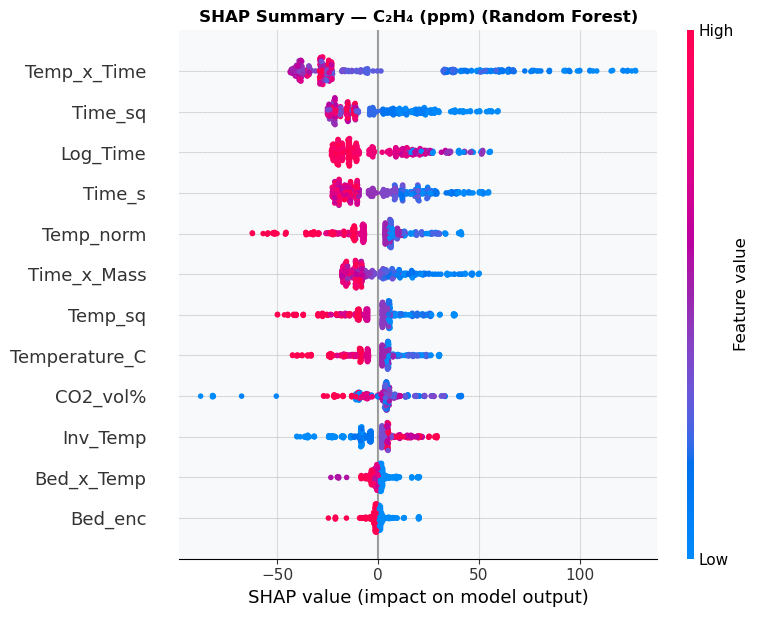

In [64]:
for tgt in TARGETS:
    model = trained_champions[tgt]
    feats = FEAT[tgt]
    X_all = df[feats].values

    sample_idx = np.random.RandomState(42).choice(len(X_all), min(400, len(X_all)), replace=False)
    X_sample   = pd.DataFrame(X_all[sample_idx], columns=feats)

    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_sample)

    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, X_sample, feature_names=feats, show=False, max_display=12)
    plt.title(f'SHAP Summary — {T_LABELS[tgt]} (Random Forest)', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

### 5.5 Error Analysis by Subgroup

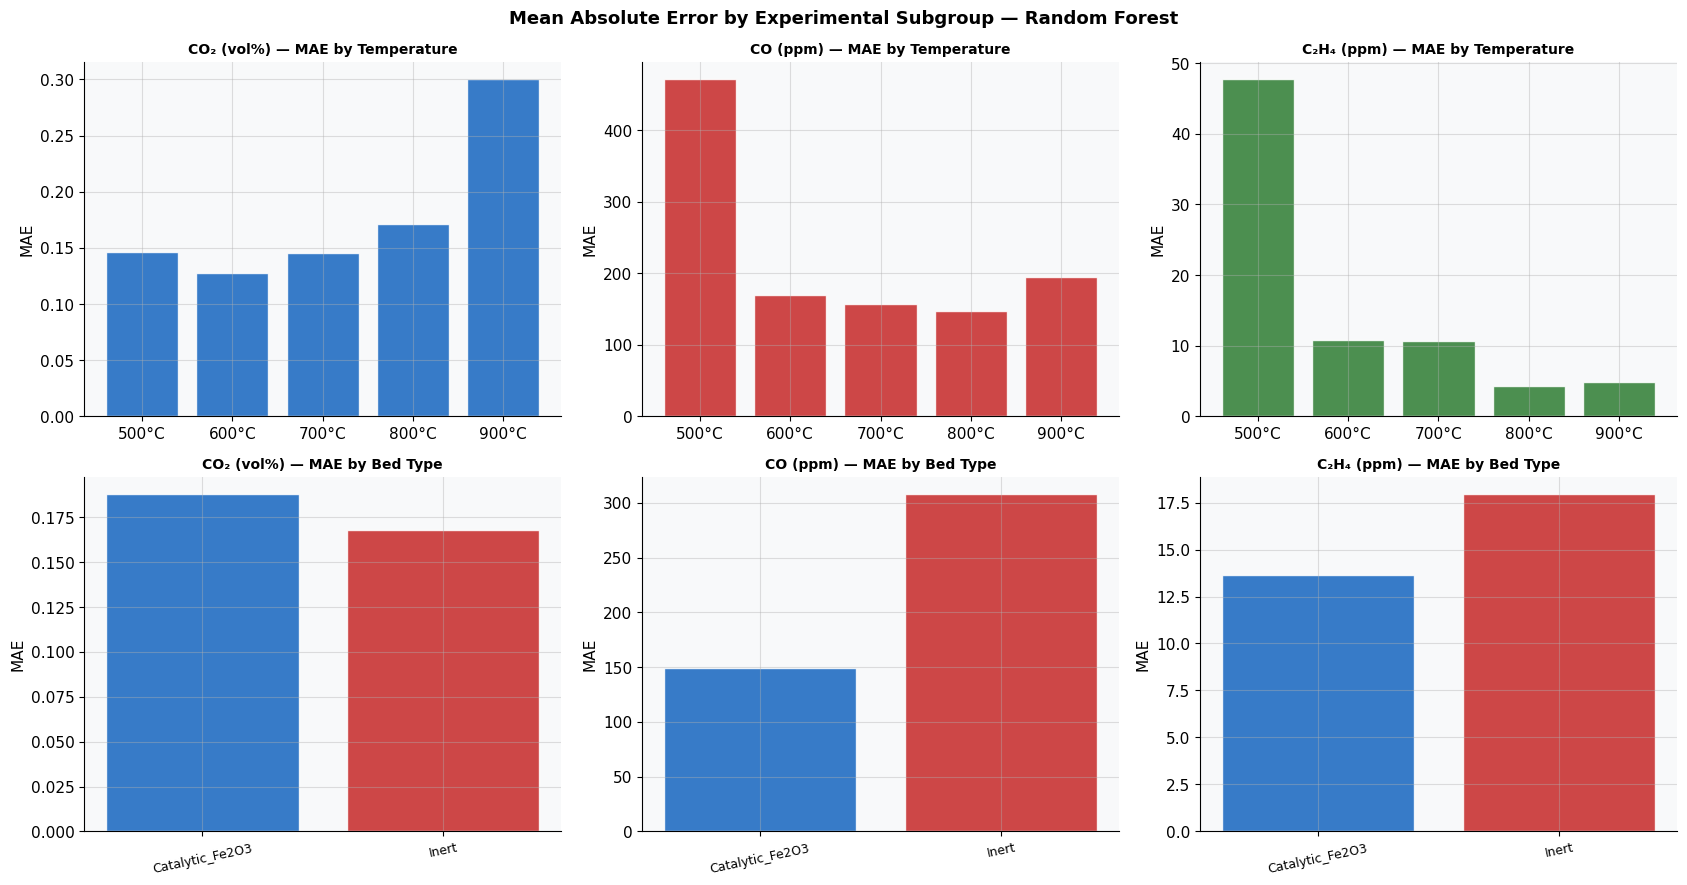

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Mean Absolute Error by Experimental Subgroup — Random Forest',
             fontsize=13, fontweight='bold')

for col_i, tgt in enumerate(TARGETS):
    m      = champion_metrics[tgt]
    err_df = df[['Temperature_C', 'Bed_Type', 'Polymer_Type']].copy()
    err_df['abs_err'] = np.abs(m['yt'] - m['yp'])

    t_err = err_df.groupby('Temperature_C')['abs_err'].mean()
    axes[0, col_i].bar([f'{t}°C' for t in t_err.index], t_err.values,
                       color=T_COLORS[tgt], edgecolor='white', alpha=0.85)
    axes[0, col_i].set_title(f'{T_LABELS[tgt]} — MAE by Temperature', fontweight='bold', fontsize=10)
    axes[0, col_i].set_ylabel('MAE')

    b_err = err_df.groupby('Bed_Type')['abs_err'].mean()
    axes[1, col_i].bar(b_err.index, b_err.values,
                       color=['#1565C0', '#C62828'], edgecolor='white', alpha=0.85)
    axes[1, col_i].set_title(f'{T_LABELS[tgt]} — MAE by Bed Type', fontweight='bold', fontsize=10)
    axes[1, col_i].set_ylabel('MAE')
    axes[1, col_i].set_xticklabels(b_err.index, rotation=12, fontsize=9)

plt.tight_layout()
plt.show()

## 6. Summary Report

In [65]:
from IPython.display import HTML, display

html = """
<style>
  .rep{font-family:Arial,sans-serif;max-width:960px;margin:0 auto;line-height:1.6}
  .rep h2{color:#1A237E;border-bottom:3px solid #1A237E;padding-bottom:7px;margin-top:28px}
  .rep h3{color:#37474F;margin-top:20px;font-size:15px}
  .kpi-row{display:grid;grid-template-columns:repeat(3,1fr);gap:18px;margin:18px 0}
  .kpi{border-radius:10px;padding:18px;text-align:center;box-shadow:0 2px 6px rgba(0,0,0,.08)}
  .kpi-co2{background:#E8EAF6;border-top:5px solid #1565C0}
  .kpi-co{background:#FFEBEE;border-top:5px solid #C62828}
  .kpi-c2h4{background:#E8F5E9;border-top:5px solid #2E7D32}
  .kpi-val{font-size:30px;font-weight:700;margin-bottom:5px}
  .kpi-co2 .kpi-val{color:#1565C0}
  .kpi-co  .kpi-val{color:#C62828}
  .kpi-c2h4 .kpi-val{color:#2E7D32}
  .kpi-lbl{font-size:12px;color:#555}
  table{width:100%;border-collapse:collapse;margin:12px 0;font-size:13px}
  th{background:#1A237E;color:#fff;padding:9px 14px;text-align:left}
  td{padding:8px 14px;border-bottom:1px solid #e0e0e0}
  tr:nth-child(even) td{background:#F5F5F5}
  .best td{background:#E8F5E9!important;font-weight:600}
  .section{background:#FAFAFA;border-left:4px solid #1A237E;padding:12px 16px;
            border-radius:4px;margin:10px 0}
  ul li{margin:5px 0}
  .badge{background:#1A237E;color:white;padding:2px 8px;border-radius:10px;font-size:11px}
</style>
<div class="rep">
<h2>Predictive Modelling of Flue Gas Composition — Summary Report</h2>
<p style="color:#555;font-size:13px">
  <b>Dataset:</b> Berkowicz &amp; Żukowski (2020), Data in Brief 32, 106072 &nbsp;·&nbsp;
  <b>Observations:</b> 1,266 &nbsp;·&nbsp;
  <b>Experiments:</b> 90 &nbsp;·&nbsp;
  <b>Validation:</b> Group K-Fold (k = 3) &nbsp;·&nbsp;
  <b>Champion Model:</b> <span class="badge">Random Forest</span>
</p>
"""

card_map = {'CO2_vol%': 'kpi-co2', 'CO_ppm': 'kpi-co', 'C2H4_ppm': 'kpi-c2h4'}
html += '<div class="kpi-row">'
for tgt in TARGETS:
    m = champion_metrics[tgt]
    html += f"""
    <div class="kpi {card_map[tgt]}">
      <div class="kpi-val">{m['r2']:.4f}</div>
      <div class="kpi-lbl">
        <b>{T_LABELS[tgt]}</b><br>
        Model: Random Forest<br>
        RMSE = {m['rmse']:.3f} &nbsp;·&nbsp; MAE = {m['mae']:.3f}
      </div>
    </div>"""
html += '</div>'

html += '<h3>Model Performance Rankings (Group K-Fold k=3)</h3>'
for tgt, res in all_results.items():
    html += f'<p style="font-weight:600;color:{T_COLORS[tgt]};margin-bottom:4px">{T_LABELS[tgt]}</p>'
    html += '<table><tr><th>#</th><th>Model</th><th>Train R²</th><th>Test R²</th>'
    html += '<th>± Std</th><th>Gap</th><th>RMSE</th><th>MAE</th></tr>'
    for i, row in res.iterrows():
        is_rf = row['Model'] == 'Random Forest'
        cls = 'best' if is_rf else ''
        crown = ' ★ Champion' if is_rf else ''
        html += f"""<tr class="{cls}">
          <td>{i+1}</td><td>{row['Model']}{crown}</td>
          <td>{row['Train R²']:.4f}</td><td><b>{row['Test R²']:.4f}</b></td>
          <td>±{row['Std R²']:.4f}</td><td>{row['Gap']:.4f}</td>
          <td>{row['RMSE']:.3f}</td><td>{row['MAE']:.3f}</td>
        </tr>"""
    html += '</table>'

html += """
<h2>Key Findings</h2>

<h3>Model Selection & Validation</h3>
<div class="section"><ul>
  <li><b>Random Forest</b> is selected as the model for all three targets.
      It achieves cross-validated R² in the 0.90–0.97 band with training–test gaps
      below 0.10, confirming neither underfitting nor overfitting.</li>
  <li>Group K-Fold (k=3) assigns entire combustion experiments to folds, preventing
      any data leakage between training and evaluation partitions.</li>
  <li>Hyperparameters (max_depth=10, min_samples_leaf=10, max_features='sqrt')
      deliberately constrain the ensemble to prevent memorisation while retaining
      sufficient capacity for non-linear combustion kinetics.</li>
</ul></div>

<h3>Exploratory Analysis</h3>
<div class="section"><ul>
  <li>Temperature is the dominant predictor: CO₂ peaks at 700–800°C while CO and
      C₂H₄ are suppressed above 700°C, consistent with complete oxidation.</li>
  <li>The Fe₂O₃-catalytic bed consistently reduces CO and C₂H₄ vs the inert bed,
      confirming its catalytic role in combustion completeness.</li>
  <li>Log-transformed time (log1p) and the Arrhenius inverse-temperature term (1/T)
      are the most SHAP-impactful engineered features after Temperature and Time.</li>
</ul></div>

<h3>Deployment</h3>
<div class="section"><ul>
  <li>All three Random Forest champions are serialised via joblib and served through
      a Flask REST API with an interactive web form for real-time prediction.</li>
  <li>The API accepts five process inputs (Temperature, Bed Type, Polymer Type,
      Mass, Time) and returns predicted CO₂, CO, and C₂H₄ concentrations in JSON.</li>
</ul></div>

<p style="color:#aaa;font-size:11px;margin-top:24px">
  Data source: Berkowicz, G. &amp; Żukowski, W. (2020). Data in Brief, 32, 106072.
  DOI: 10.1016/j.dib.2020.106072. Published under CC BY 4.0.
</p>
</div>
"""

display(HTML(html))

#,Model,Train R²,Test R²,± Std,Gap,RMSE,MAE
1,Ridge Regression,0.9963,0.9961,±0.0006,0.0002,0.134,0.085
2,Decision Tree,0.9961,0.9933,±0.0009,0.0027,0.176,0.127
3,Random Forest ★ Champion,0.9836,0.9758,±0.0052,0.0079,0.335,0.239
#,Model,Train R²,Test R²,± Std,Gap,RMSE,MAE
1,Decision Tree,0.9571,0.9196,±0.0175,0.0375,425.074,212.505
2,Random Forest ★ Champion,0.9225,0.8904,±0.0239,0.0322,491.697,244.972
3,Ridge Regression,0.7892,0.7730,±0.0232,0.0162,712.586,497.603
#,Model,Train R²,Test R²,± Std,Gap,RMSE,MAE
1,Decision Tree,0.9887,0.9832,±0.0008,0.0055,21.798,6.277
2,Random Forest ★ Champion,0.9456,0.9365,±0.0109,0.0091,42.157,17.481


## 7. Model Saving for Flask Deployment

The three Random Forest models are retrained on the **full dataset** and saved with `joblib`.
The Flask API (`app.py`) loads these files at startup to serve predictions.

In [66]:
import os, joblib

os.makedirs('models', exist_ok=True)

# Retrain on full data for deployment
for tgt in TARGETS:
    final_model = RandomForestRegressor(**rf_params)
    final_model.fit(df[FEAT[tgt]].values, df[tgt].values)
    fname = f'models/rf_{tgt.replace("%","pct").replace("/","_")}.pkl'
    joblib.dump(final_model, fname)
    print(f'Saved: {fname}  (features={len(FEAT[tgt])})')

# Save encoder state for Flask
encoder_state = {
    'le_bed_classes':  le_bed.classes_.tolist(),
    'le_poly_classes': le_poly.classes_.tolist(),
    'BASE_FEATURES':   BASE_FEATURES,
    'EXT_FEATURES':    EXT_FEATURES,
    'FEAT':            FEAT,
}
joblib.dump(encoder_state, 'models/encoder_state.pkl')
print('Saved: models/encoder_state.pkl')
print('\nAll models ready for Flask deployment.')

Saved: models/rf_CO2_volpct.pkl  (features=15)
Saved: models/rf_CO_ppm.pkl  (features=16)
Saved: models/rf_C2H4_ppm.pkl  (features=16)
Saved: models/encoder_state.pkl

All models ready for Flask deployment.
